# Exercise 0: Maximum likelihood for a Gaussian

**Goal.** Fit the mean and variance of a Gaussian to data by maximum likelihood: first with pen and paper, then numerically with gradient descent in PyTorch.

This is a warm-up, but the second half matters later. The training loop you write here (trainable parameters → negative log-likelihood → `Adam` → `.backward()`) is exactly the loop you will reuse in Exercise 2 to train a mixture density network.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## Part A: Pen and paper

Given i.i.d. samples $x_1, \dots, x_N \sim \mathcal{N}(\mu, \sigma^2)$, the log-likelihood of the parameters is

$$\log p(x_{1:N} \mid \mu, \sigma^2) = \sum_{i=1}^N \log \mathcal{N}(x_i \mid \mu, \sigma^2) = -\frac{N}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^N (x_i - \mu)^2 .$$

**Exercise 0a (on paper).** Derive the maximum likelihood estimators $\hat\mu$ and $\hat\sigma^2$. Take the derivative of the log-likelihood with respect to $\mu$ and to $\sigma^2$, set each to zero, and solve.

## Part B: Maximum likelihood in code

### Simulated data

We draw a dataset from a Gaussian whose parameters we know, so we can check whether we recover them.

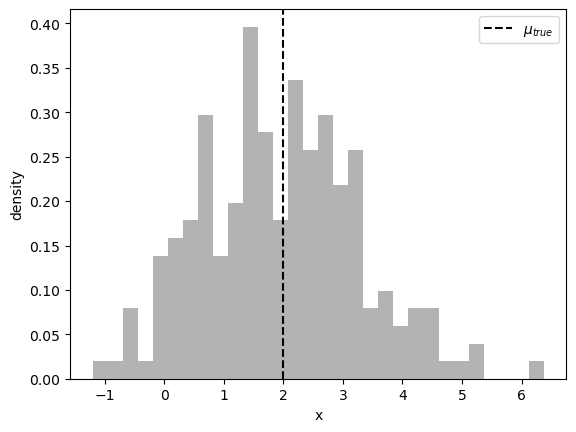

In [2]:
MU_TRUE = 2.0
SIGMA_TRUE = 1.5
N_SAMPLES = 200

data = rng.normal(MU_TRUE, SIGMA_TRUE, size=N_SAMPLES)

plt.hist(data, bins=30, density=True, color="0.7")
plt.axvline(MU_TRUE, color="k", ls="--", label=r"$\mu_{true}$")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()

### The closed-form answer

**Exercise 0b.** Use the estimators you derived in Part A to compute $\hat\mu$ and $\hat\sigma^2$ from `data`.

In [ ]:
# EXERCISE 0b: compute the maximum likelihood estimates from `data` with your formulas from Part A.
#   mu_hat     -> MLE of the mean (a float)
#   sigma2_hat -> MLE of the variance (a float). Careful: divide by N, not N - 1.
mu_hat = ...
sigma2_hat = ...

print(f"mu_hat     = {mu_hat:.4f}   (true {MU_TRUE})")
print(f"sigma2_hat = {sigma2_hat:.4f}   (true {SIGMA_TRUE**2})")

In [ ]:
# Sanity check
assert np.isclose(mu_hat, data.mean()), "mu_hat should equal the sample mean"
assert np.isclose(sigma2_hat, data.var(ddof=0)), "sigma2_hat should divide by N (ddof=0), not N - 1"
print("Closed-form estimates look right.")

### The same fit, by gradient descent

For a Gaussian we can solve for the MLE by hand. For most models, including the neural networks in Exercises 2 and 3, we can't. Instead we minimize the **negative log-likelihood (NLL)** numerically:

$$\text{NLL}(\mu, \sigma) = -\frac{1}{N}\sum_{i=1}^N \log \mathcal{N}(x_i \mid \mu, \sigma^2) = \frac{1}{N}\sum_{i=1}^N \left[\frac{(x_i-\mu)^2}{2\sigma^2} + \log\sigma + \tfrac12\log 2\pi\right].$$

We average over data points rather than summing, so the scale of the loss doesn't depend on $N$.

A common trick is that we optimize $\log\sigma$ rather than $\sigma$. Any real value of $\log\sigma$ gives a valid, positive $\sigma = e^{\log\sigma}$, so the optimizer can never step into a negative variance.

In [5]:
data_t = torch.tensor(data, dtype=torch.float32)

**Exercise 0c.** Implement `gaussian_nll(x, mu, log_sigma)`: the mean negative log-likelihood of the samples `x` under $\mathcal{N}(\mu, \sigma^2)$, with $\sigma = e^{\log\sigma}$. Use torch operations so gradients can flow through it.

In [ ]:
def gaussian_nll(x: torch.Tensor, mu: torch.Tensor, log_sigma: torch.Tensor) -> torch.Tensor:
    """Mean negative log-likelihood of samples x under N(mu, exp(log_sigma)^2). Returns a scalar tensor."""
    # EXERCISE 0c: compute the per-sample log density  -(x - mu)^2 / (2 sigma^2) - log(sigma) - 0.5 log(2 pi),
    # then return minus its mean. Use torch.exp(log_sigma) for sigma and math.log(2 * math.pi) for the constant.
    sigma = ...
    log_prob = ...
    return -log_prob.mean()

In [ ]:
# Sanity check against PyTorch's built-in Normal distribution
x_test = torch.tensor([0.3, -1.2, 2.5])
mu_test, log_sigma_test = torch.tensor(0.5), torch.tensor(0.2)
expected = -torch.distributions.Normal(mu_test, log_sigma_test.exp()).log_prob(x_test).mean()
assert torch.allclose(gaussian_nll(x_test, mu_test, log_sigma_test), expected, atol=1e-6)
print("gaussian_nll matches torch.distributions.Normal.")

**Exercise 0d.** Fit `mu` and `log_sigma` by minimizing `gaussian_nll` with `torch.optim.Adam`. Every training step has the same four parts:

1. `optimizer.zero_grad()`: clear the gradients from the previous step.
2. Compute the loss.
3. `loss.backward()`: compute the gradients of the loss with respect to the parameters.
4. `optimizer.step()`: update the parameters.

We also record the loss and the parameter values at every step, for the plots below.

In [ ]:
n_steps = 1000
losses, trajectory = [], []

# EXERCISE 0d:
#   1. Create two scalar tensors with requires_grad=True: `mu` starting at 0.0 and `log_sigma` starting at 0.0.
#   2. Create `optimizer = torch.optim.Adam([...], lr=0.05)` over both parameters.
#   3. Inside the loop: zero the gradients, compute `loss = gaussian_nll(data_t, mu, log_sigma)`,
#      call loss.backward(), then optimizer.step().
mu = ...
log_sigma = ...
optimizer = ...

for step in range(n_steps):
    ...  # zero_grad
    loss = ...  # gaussian_nll(data_t, mu, log_sigma)
    ...  # loss.backward()
    ...  # optimizer.step()
    losses.append(loss.item())
    trajectory.append((mu.item(), log_sigma.item()))

In [ ]:
mu_fit = mu.item()
sigma2_fit = math.exp(2 * log_sigma.item())

print(f"{'':14s}{'mu':>10s}{'sigma^2':>10s}")
print(f"{'true':14s}{MU_TRUE:10.4f}{SIGMA_TRUE**2:10.4f}")
print(f"{'closed form':14s}{mu_hat:10.4f}{sigma2_hat:10.4f}")
print(f"{'gradient':14s}{mu_fit:10.4f}{sigma2_fit:10.4f}")
assert abs(mu_fit - mu_hat) < 1e-2 and abs(sigma2_fit - sigma2_hat) < 1e-2, \
    "the gradient-based fit hasn't converged to the closed-form MLE"

# NLL over a grid of (mu, log_sigma), to see the path the optimizer took
mu_axis = np.linspace(-0.5, 3.5, 150)
log_sigma_axis = np.linspace(-0.5, 1.5, 150)
M, LS = np.meshgrid(mu_axis, log_sigma_axis)
nll_grid = ((data - M[..., None]) ** 2 / (2 * np.exp(2 * LS[..., None])) + LS[..., None]).mean(-1) + 0.5 * np.log(2 * np.pi)
traj = np.array(trajectory)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses)
axes[0].set(xlabel="step", ylabel="NLL", title="Training loss")
axes[1].contour(M, LS, nll_grid, levels=30, cmap="viridis")
axes[1].plot(traj[:, 0], traj[:, 1], "k.-", ms=2, lw=0.8, label="Adam trajectory")
axes[1].plot(mu_hat, 0.5 * np.log(sigma2_hat), "r*", ms=14, label="closed-form MLE")
axes[1].set(xlabel=r"$\mu$", ylabel=r"$\log\sigma$", title="NLL landscape")
axes[1].legend()
plt.tight_layout()
plt.show()

## From two numbers to a neural network

This loop (trainable parameters, an NLL loss, `Adam`, `.backward()`) is exactly the pattern Exercise 2 uses to train an MDN. The only thing that changes is what the parameters are (a neural network instead of two numbers) and what the NLL is computed over (a mixture, and conditioned on `x`).

## Questions to think about

1. `data.var(ddof=1)` gives a slightly larger value than your $\hat\sigma^2$. Which one is the MLE, and why is the MLE of the variance biased? Does the difference matter for $N = 200$? For $N = 5$?
2. What could go wrong if you optimized `sigma` directly instead of `log_sigma`, especially with a large learning rate?
3. We averaged the NLL over data points instead of summing. How does that change the gradients, and what would you need to change about the learning rate if you summed?
4. Suppose the data came from two well-separated Gaussians. What would the single-Gaussian MLE give you, and what kind of model would you need instead? Keep this in mind for Exercise 2.